In [1]:
# TP6.3 — AR and ARIMA models


#Goal: baseline (persistence), AR(p), ARIMA(p,d,q), evaluation + residual analysis.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error


In [3]:
import sys, subprocess

try:
    import statsmodels
    print("statsmodels OK:", statsmodels.__version__)
except Exception:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-U", "statsmodels"])
    import statsmodels
    print("statsmodels installed:", statsmodels.__version__)


statsmodels installed: 0.14.6


In [4]:
import os

ROOT = r"D:\UFR STGI\second Semester\Machine Learning\cours_ia"

def find_file(root, filename):
    for dirpath, _, filenames in os.walk(root):
        if filename in filenames:
            return os.path.join(dirpath, filename)
    return None

csv_path = find_file(ROOT, "train.csv")
print("Found train.csv:", csv_path)

if csv_path is None:
    raise FileNotFoundError(f"train.csv not found under {ROOT}. Change ROOT or move train.csv.")

df = pd.read_csv(csv_path, parse_dates=["datetime"])
serie = df.set_index("datetime")["count"].sort_index()
serie = serie.asfreq("h").ffill()

print("serie ready:", serie.shape, "| freq:", serie.index.inferred_freq)


Found train.csv: D:\UFR STGI\second Semester\Machine Learning\cours_ia\IA prédictive\TP6_Series_Temporelles\train.csv
serie ready: (17256,) | freq: h


In [5]:
split_date = "2012-10-01"

train = serie.loc[:split_date]
test  = serie.loc[split_date:]

print("Train:", train.shape, "Test:", test.shape)
print("Train span:", train.index.min(), "->", train.index.max())
print("Test  span:", test.index.min(),  "->", test.index.max())


Train: (15360,) Test: (1920,)
Train span: 2011-01-01 00:00:00 -> 2012-10-01 23:00:00
Test  span: 2012-10-01 00:00:00 -> 2012-12-19 23:00:00


In [6]:
def compute_metrics(y_true, y_pred):
    y_true = pd.Series(y_true).dropna()
    y_pred = pd.Series(y_pred).dropna()
    common = y_true.index.intersection(y_pred.index)
    y_true = y_true.loc[common]
    y_pred = y_pred.loc[common]

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return mae, rmse


In [7]:
# Persistence baseline: predict the next hour as the previous hour
baseline_pred = test.shift(1).dropna()
baseline_true = test.loc[baseline_pred.index]

mae_base, rmse_base = compute_metrics(baseline_true, baseline_pred)
print(f"Persistence baseline -> MAE: {mae_base:.2f} | RMSE: {rmse_base:.2f}")


Persistence baseline -> MAE: 61.48 | RMSE: 108.93


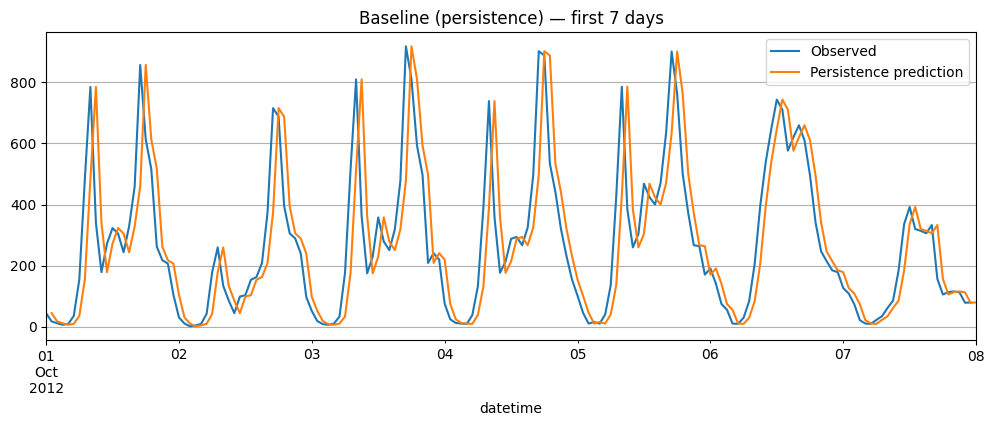

In [8]:
horizon = 24 * 7

plt.figure(figsize=(12,4))
test.iloc[:horizon].plot(label="Observed")
baseline_pred.iloc[:horizon].plot(label="Persistence prediction")
plt.title("Baseline (persistence) — first 7 days")
plt.legend()
plt.grid(True)
plt.show()


In [9]:
from statsmodels.tsa.ar_model import AutoReg

orders = [6, 12, 24]  # # choose based on PACF intuition (daily patterns often show 24)
ar_results = []

for p in orders:
    ar_model = AutoReg(train, lags=p, old_names=False)
    ar_fit = ar_model.fit()

    ar_pred = ar_fit.predict(start=test.index[0], end=test.index[-1])
    mae, rmse = compute_metrics(test, ar_pred)

    ar_results.append({"p": p, "AIC": ar_fit.aic, "MAE": mae, "RMSE": rmse})

ar_table = pd.DataFrame(ar_results).sort_values("RMSE")
display(ar_table)


,p,AIC,MAE,RMSE
2,24,164537.181921,124.766283,174.470838
1,12,170508.021480,130.757427,191.158649
0,6,172305.642227,130.676512,191.292627


In [10]:
best_p = int(ar_table.iloc[0]["p"])
print("Best p (by RMSE):", best_p)

ar_best = AutoReg(train, lags=best_p, old_names=False).fit()
ar_pred = ar_best.predict(start=test.index[0], end=test.index[-1])

mae_ar, rmse_ar = compute_metrics(test, ar_pred)
print(f"AR(p={best_p}) -> MAE: {mae_ar:.2f} | RMSE: {rmse_ar:.2f} | AIC: {ar_best.aic:.2f}")


Best p (by RMSE): 24
AR(p=24) -> MAE: 124.77 | RMSE: 174.47 | AIC: 164537.18


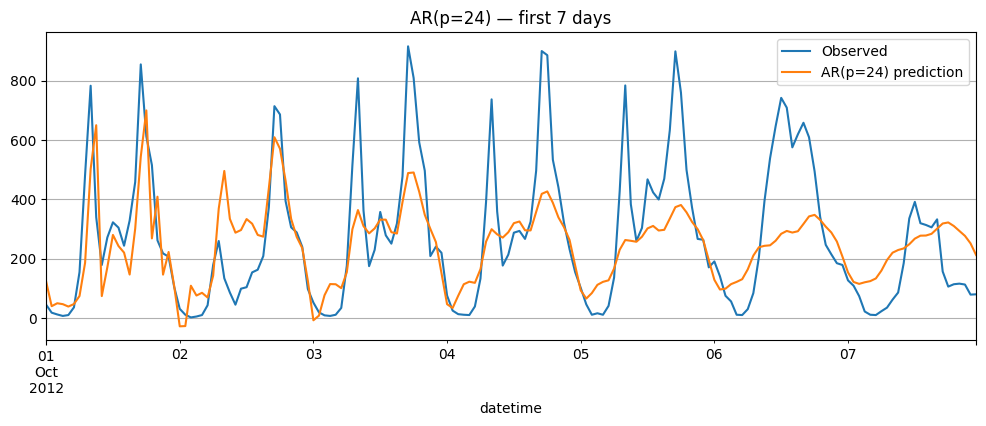

In [11]:
plt.figure(figsize=(12,4))
test.iloc[:horizon].plot(label="Observed")
ar_pred.iloc[:horizon].plot(label=f"AR(p={best_p}) prediction")
plt.title(f"AR(p={best_p}) — first 7 days")
plt.legend()
plt.grid(True)
plt.show()


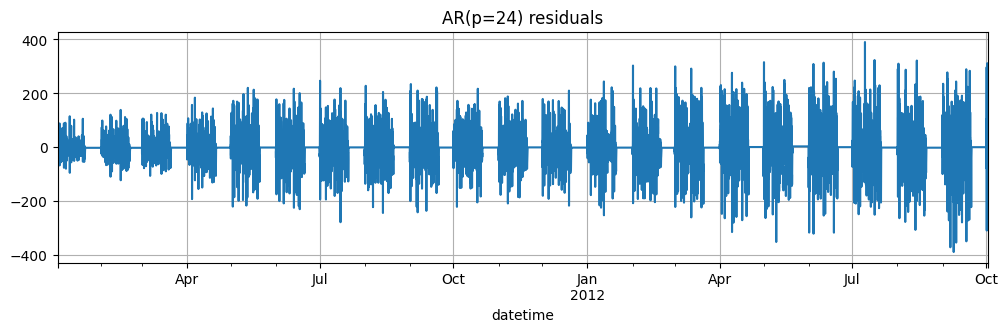

<Figure size 1200x300 with 0 Axes>

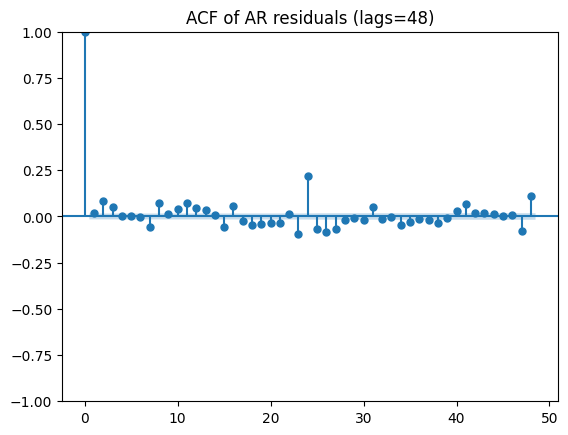

In [12]:
from statsmodels.graphics.tsaplots import plot_acf

ar_resid = ar_best.resid

plt.figure(figsize=(12,3))
ar_resid.plot(title=f"AR(p={best_p}) residuals")
plt.grid(True)
plt.show()

plt.figure(figsize=(12,3))
plot_acf(ar_resid.dropna(), lags=48)
plt.title("ACF of AR residuals (lags=48)")
plt.show()


In [13]:
# AR interpretation

# Do the residuals look random (noise-like)?
# If residual ACF still has strong structure, AR alone may be insufficient.
# In that case, adding an MA component (ARIMA) can help.


In [14]:
# Choose d based on TP6.2 stationarity:
# If the raw series is non-stationary and diff1 was needed -> d = 1
# If you already decided to model a differenced series, then use d = 0 here.
d = 1
print("Using d =", d)


Using d = 1


In [15]:
from statsmodels.tsa.arima.model import ARIMA

def fit_arima(order):
    model = ARIMA(train, order=order)
    fit = model.fit()
    pred = fit.predict(start=test.index[0], end=test.index[-1])
    mae, rmse = compute_metrics(test, pred)
    return fit, pred, mae, rmse

orders = [(2,d,2), (5,d,0), (3,d,3)]
arima_rows = []
arima_fits = {}

for order in orders:
    fit, pred, mae, rmse = fit_arima(order)
    arima_rows.append({"order": order, "AIC": fit.aic, "MAE": mae, "RMSE": rmse})
    arima_fits[order] = (fit, pred)

arima_table = pd.DataFrame(arima_rows).sort_values("RMSE")
display(arima_table)


C:\Users\VICTUS\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\VICTUS\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


,order,AIC,MAE,RMSE
0,"(2, 1, 2)",172235.854151,135.539142,184.971543
2,"(3, 1, 3)",172205.951878,134.979172,185.362538
1,"(5, 1, 0)",173877.401740,133.888924,203.271483


Best ARIMA order (by RMSE): (2, 1, 2)
ARIMA(2, 1, 2) -> MAE: 135.54 | RMSE: 184.97 | AIC: 172235.85


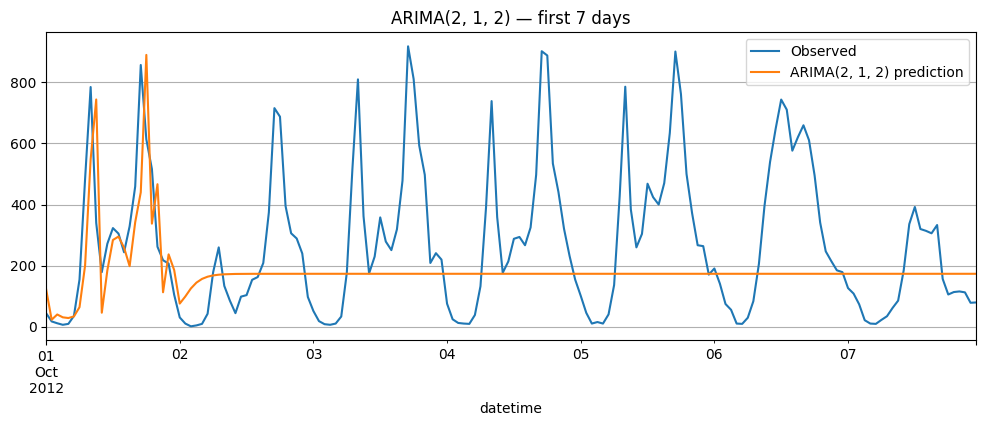

In [16]:
best_order = tuple(arima_table.iloc[0]["order"])
print("Best ARIMA order (by RMSE):", best_order)

arima_best_fit, arima_pred = arima_fits[best_order]
mae_arima = float(arima_table.iloc[0]["MAE"])
rmse_arima = float(arima_table.iloc[0]["RMSE"])

print(f"ARIMA{best_order} -> MAE: {mae_arima:.2f} | RMSE: {rmse_arima:.2f} | AIC: {arima_best_fit.aic:.2f}")

plt.figure(figsize=(12,4))
test.iloc[:horizon].plot(label="Observed")
arima_pred.iloc[:horizon].plot(label=f"ARIMA{best_order} prediction")
plt.title(f"ARIMA{best_order} — first 7 days")
plt.legend()
plt.grid(True)
plt.show()


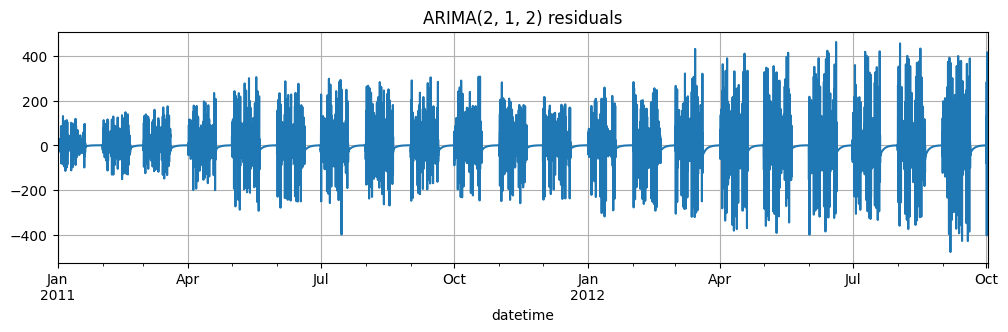

<Figure size 1200x300 with 0 Axes>

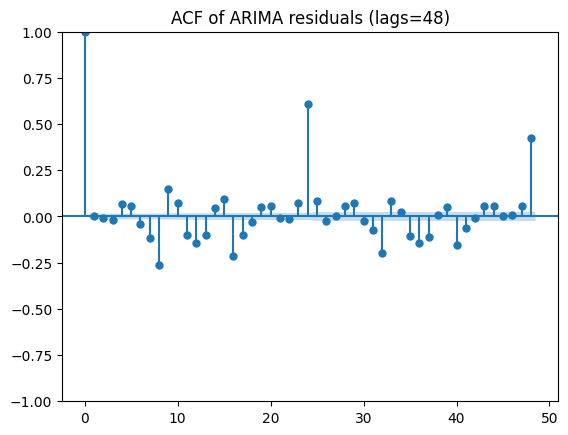

In [17]:
arima_resid = arima_best_fit.resid

plt.figure(figsize=(12,3))
pd.Series(arima_resid).plot(title=f"ARIMA{best_order} residuals")
plt.grid(True)
plt.show()

plt.figure(figsize=(12,3))
plot_acf(pd.Series(arima_resid).dropna(), lags=48)
plt.title("ACF of ARIMA residuals (lags=48)")
plt.show()


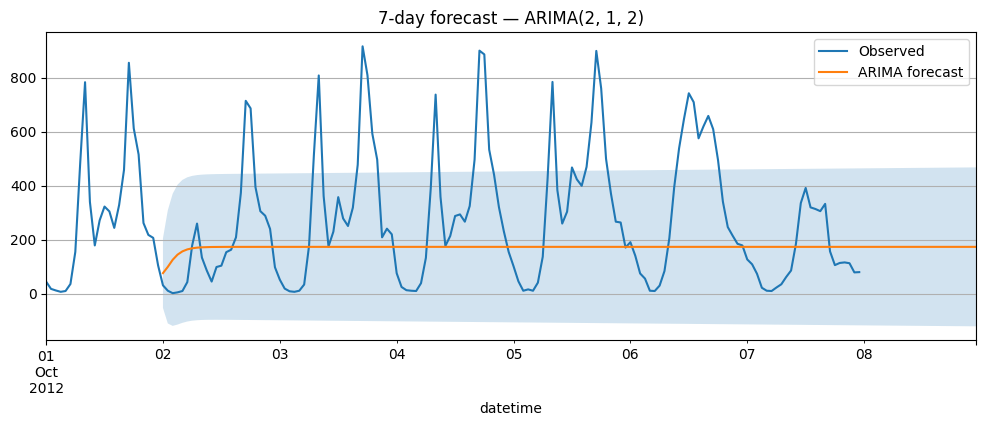

In [18]:
forecast = arima_best_fit.get_forecast(steps=24*7)
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()

fig, ax = plt.subplots(figsize=(12,4))
test.iloc[:24*7].plot(ax=ax, label="Observed")
forecast_mean.plot(ax=ax, label="ARIMA forecast")

ax.fill_between(
    forecast_ci.index,
    forecast_ci.iloc[:, 0],
    forecast_ci.iloc[:, 1],
    alpha=0.2
)

ax.set_title(f"7-day forecast — ARIMA{best_order}")
ax.legend()
ax.grid(True)
plt.show()


In [19]:
summary = pd.DataFrame([
    {"Model": "Persistence", "MAE": mae_base, "RMSE": rmse_base, "AIC": np.nan},
    {"Model": f"AR(p={best_p})", "MAE": mae_ar, "RMSE": rmse_ar, "AIC": ar_best.aic},
    {"Model": f"ARIMA{best_order}", "MAE": mae_arima, "RMSE": rmse_arima, "AIC": arima_best_fit.aic},
])

display(summary.sort_values("RMSE"))


,Model,MAE,RMSE,AIC
0,Persistence,61.477332,108.930556,NaN
1,AR(p=24),124.766283,174.470838,164537.181921
2,"ARIMA(2, 1, 2)",135.539142,184.971543,172235.854151


In [20]:
# TP6.3 — Synthesis (6–8 lines)

# Compare baseline vs AR vs ARIMA:
# Does ARIMA clearly beat the persistence baseline (RMSE/MAE)?
# Do residuals look more like noise for ARIMA than AR?
# At what horizon do errors grow quickly (hours vs days)?
# What remains hard (peaks, weekends, weather effects)?
# What you would try next: SARIMA (seasonal), SARIMAX (exogenous), supervised models (TP6.4).
